# 🧩 Caso N°3: Fintual – Segmentación de Clientes
### Curso: Marketing Analytics – Universidad Adolfo Ibáñez
**Integrantes:** Javier Aguilera T., Matías Garín A., Matías Olea T.

## 1️⃣ Análisis Exploratorio y Preparación de Datos
### 1.1 Estadísticas descriptivas

In [2]:
# =====================================================
# 📦 1. Carga de librerías y lectura del dataset Fintual
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (8, 5)

# Cargar dataset
df = pd.read_csv("../data/fintual_users_dataset_selected.csv")

# Vista general
print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (6478, 5)


,age,total_invested,risk_tolerance,months_active,app_sessions_month
0,35,42433,2,3,13
1,30,18370,4,6,16
2,37,3224109,1,12,16
3,44,222139,4,10,18
4,30,42501,3,6,21


In [6]:
# =====================================================
# 📊 1.1 Estadísticas descriptivas
# =====================================================

desc = df.describe(percentiles=[0.25, 0.5, 0.75]).T
descriptive_stats = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print("Estadísticas descriptivas seleccionadas:")
descriptive_stats


Estadísticas descriptivas seleccionadas:


,mean,std,min,25%,50%,75%,max
age,31.613307,7.664961e+00,18.0,26.00,31.0,37.00,63.0
total_invested,372081.131831,1.020677e+06,290.0,31077.25,100110.0,322179.25,37280895.0
risk_tolerance,2.669497,1.234532e+00,-2.0,2.00,3.0,3.00,5.0
months_active,7.678296,7.955581e+00,1.0,2.00,5.0,11.00,72.0
app_sessions_month,18.894257,6.021917e+00,4.0,15.00,18.0,22.00,56.0


### 1.2 Distribuciones de las variables

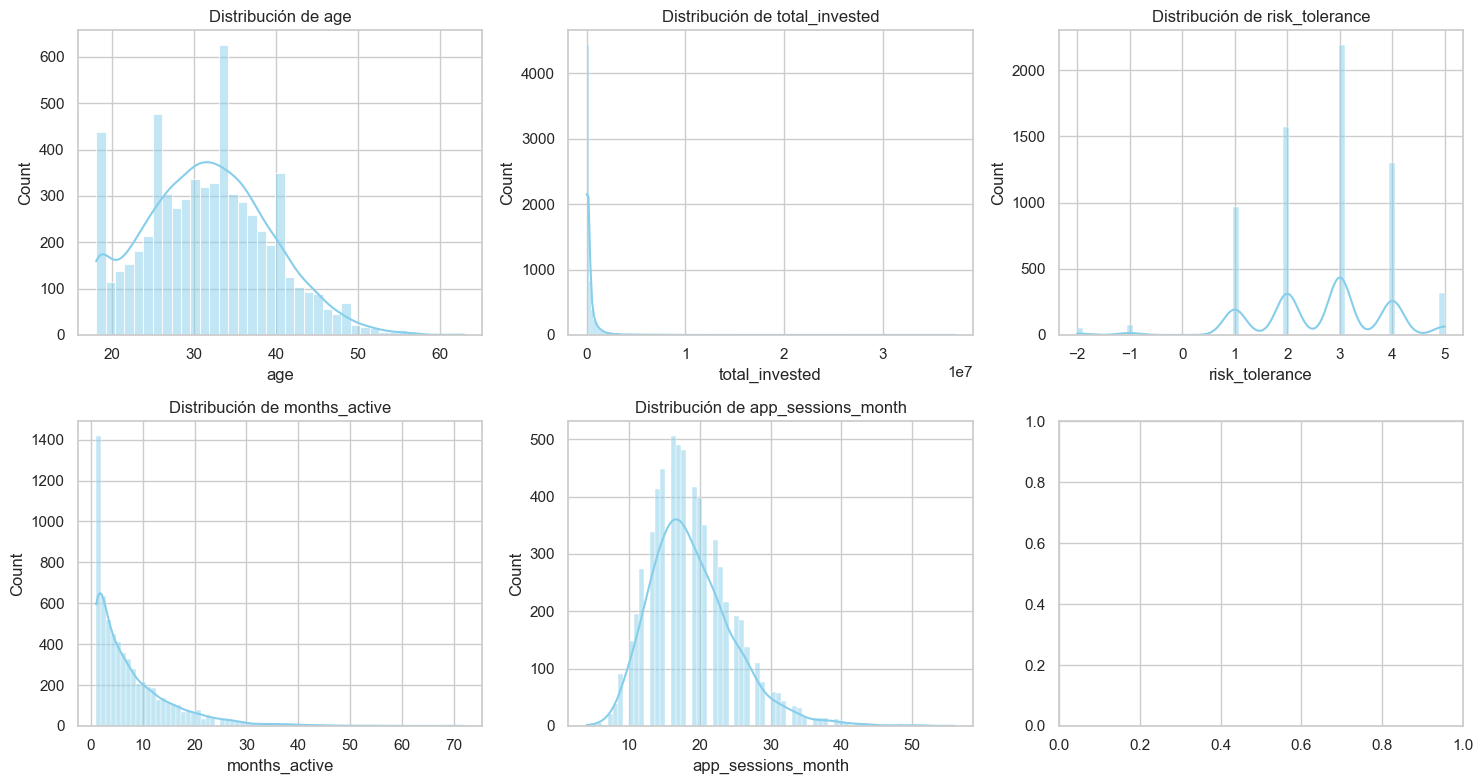

In [7]:
# =====================================================
# 🧮 1.2 Distribuciones de las variables
# =====================================================

vars_numericas = ['age', 'total_invested', 'risk_tolerance', 'months_active', 'app_sessions_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()


### 1.3 Eliminación de outliers

In [8]:
# =====================================================
# 🚫 1.3 Eliminación de outliers
# =====================================================

# Criterios de limpieza
condicion = (df['total_invested'] <= 30_000_000) & (df['risk_tolerance'].between(1, 4))

df_limpio = df[condicion].copy()

print("Registros iniciales:", len(df))
print("Registros eliminados:", len(df) - len(df_limpio))
print("Registros finales:", len(df_limpio))


Registros iniciales: 6478
Registros eliminados: 449
Registros finales: 6029


### 1.4 Análisis de valores faltantes

In [9]:
# =====================================================
# 🔍 1.4 Análisis de valores faltantes
# =====================================================

missing = df_limpio.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No existen valores faltantes en el dataset.")
else:
    print("⚠️ Existen valores faltantes:")
    print(missing)


✅ No existen valores faltantes en el dataset.


### 1.5 Matriz de correlación

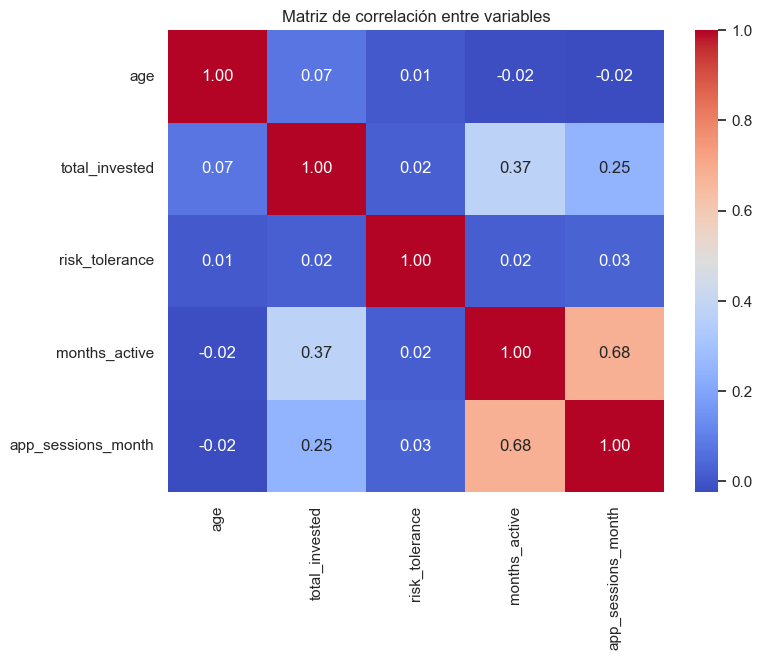

app_sessions_month  months_active         0.682755
months_active       app_sessions_month    0.682755
                    total_invested        0.372421
total_invested      months_active         0.372421
                    app_sessions_month    0.245163
app_sessions_month  total_invested        0.245163
dtype: float64

In [10]:
# =====================================================
# 🔥 1.5 Matriz de correlación
# =====================================================

corr = df_limpio.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables")
plt.show()

# Identificar las 3 correlaciones más altas en magnitud
corr_pairs = corr.unstack().sort_values(key=lambda x: abs(x), ascending=False)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs.head(6)


### 1.6 Visualizaciones exploratorias

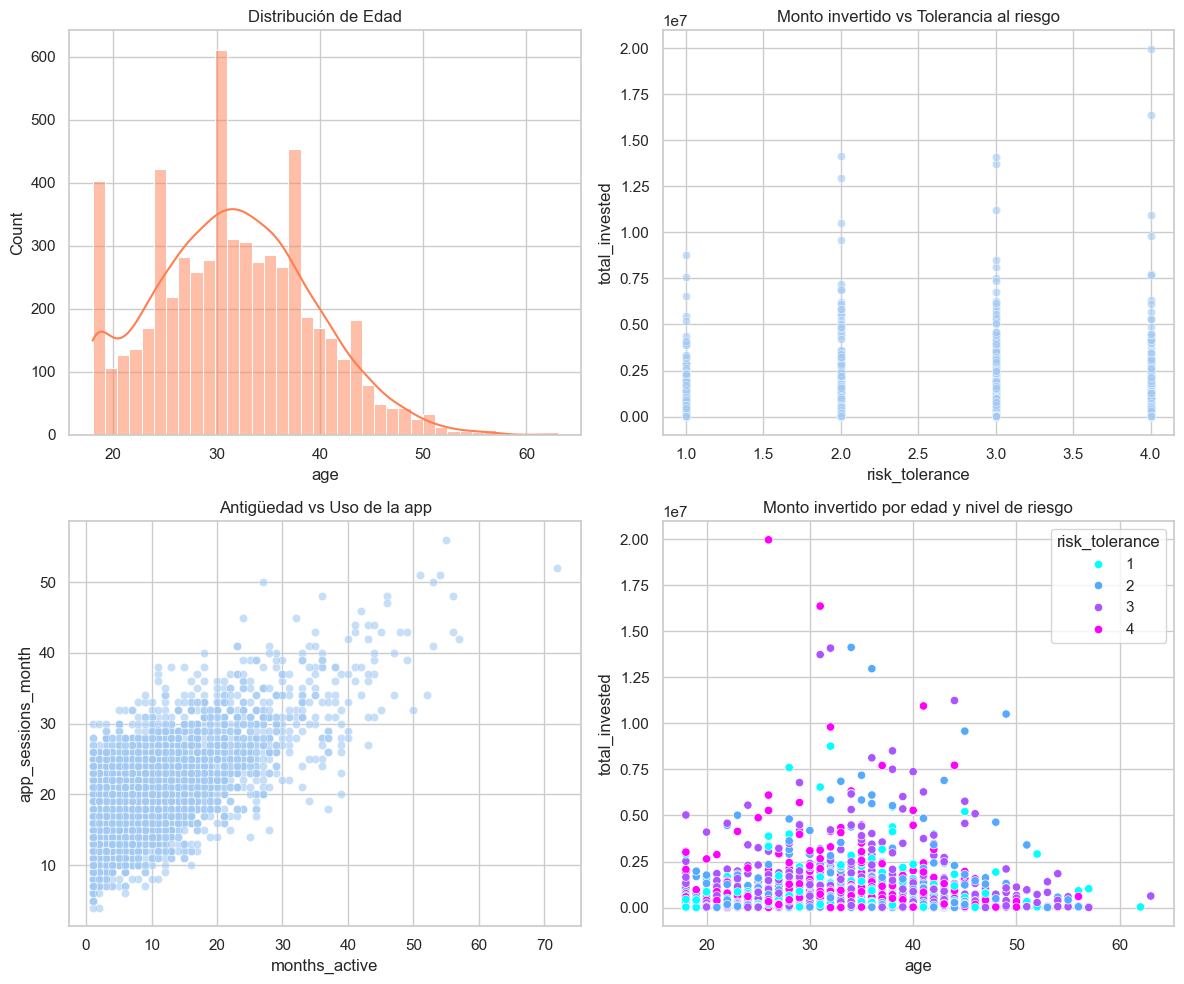

In [11]:
# =====================================================
# 📈 1.6 Visualizaciones exploratorias
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Histograma de edades
sns.histplot(df_limpio['age'], kde=True, ax=axes[0,0], color='coral')
axes[0,0].set_title("Distribución de Edad")

# (b) Dispersión inversión vs riesgo
sns.scatterplot(data=df_limpio, x='risk_tolerance', y='total_invested', ax=axes[0,1], alpha=0.6)
axes[0,1].set_title("Monto invertido vs Tolerancia al riesgo")

# (c) Dispersión antigüedad vs sesiones mensuales
sns.scatterplot(data=df_limpio, x='months_active', y='app_sessions_month', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title("Antigüedad vs Uso de la app")

# (d) Visualización adicional: inversión vs edad
sns.scatterplot(data=df_limpio, x='age', y='total_invested', ax=axes[1,1], hue='risk_tolerance', palette='cool')
axes[1,1].set_title("Monto invertido por edad y nivel de riesgo")

plt.tight_layout()
plt.show()


## 2️⃣ Clustering Jerárquico
### 2.1 Estandarización

In [13]:
# =====================================================
# 📏 2.1 Estandarización de variables
# =====================================================

from sklearn.preprocessing import StandardScaler

# Seleccionar las variables numéricas relevantes
X = df_limpio[['age', 'total_invested', 'risk_tolerance', 'months_active', 'app_sessions_month']]

# Aplicar estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para mayor legibilidad
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Verificar media ≈ 0 y std ≈ 1
print("Media por variable (debe ser cercana a 0):")
print(df_scaled.mean().round(3))
print("\nDesviación estándar (debe ser cercana a 1):")
print(df_scaled.std().round(3))


Media por variable (debe ser cercana a 0):
age                  -0.0
total_invested        0.0
risk_tolerance        0.0
months_active         0.0
app_sessions_month   -0.0
dtype: float64

Desviación estándar (debe ser cercana a 1):
age                   1.0
total_invested        1.0
risk_tolerance        1.0
months_active         1.0
app_sessions_month    1.0
dtype: float64


### 2.2 Dendrograma (20 primeros usuarios)


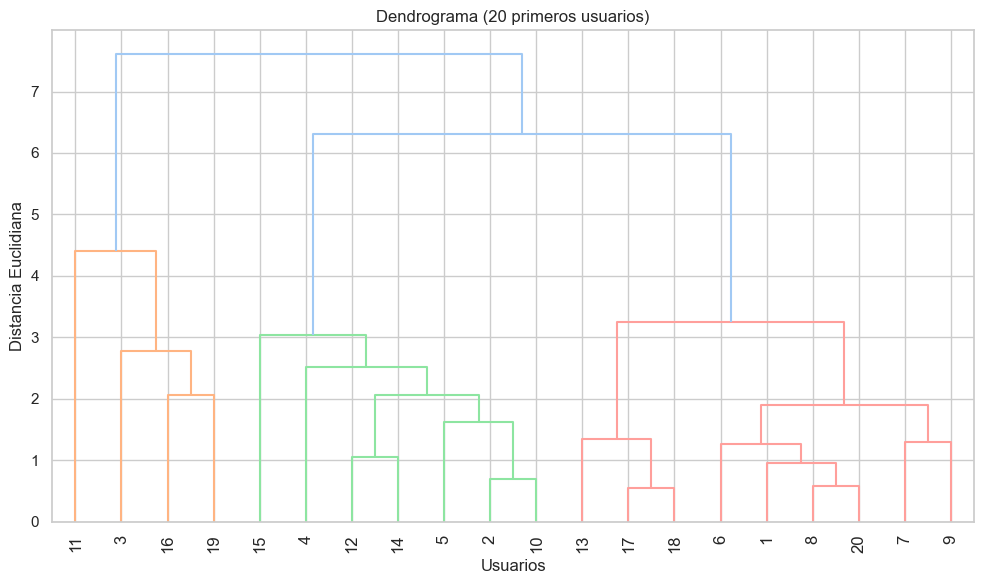

In [14]:
# =====================================================
# 🌳 2.2 Dendrograma de los primeros 20 usuarios
# =====================================================

from scipy.cluster.hierarchy import dendrogram, linkage

# Tomar solo los primeros 20 usuarios después de limpiar outliers
X_sample = df_scaled.iloc[:20, :]

# Calcular la matriz de ligamiento
Z = linkage(X_sample, method='ward')

# Graficar dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=range(1, 21), leaf_rotation=90)
plt.title("Dendrograma (20 primeros usuarios)")
plt.xlabel("Usuarios")
plt.ylabel("Distancia Euclidiana")
plt.tight_layout()
plt.show()


### 2.3 Caracterización de clusters

In [15]:
# =====================================================
# ✂️ 2.2 Corte del dendrograma y asignación de clusters
# =====================================================

from scipy.cluster.hierarchy import fcluster

# Definir el número de clusters (ajústalo luego según el dendrograma visual)
n_clusters = 3  # valor inicial tentativo, se puede modificar
clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Agregar etiquetas al subset original
df_sample_clusters = X_sample.copy()
df_sample_clusters['cluster'] = clusters

print("Asignación de clusters para los primeros 20 usuarios:")
df_sample_clusters


Asignación de clusters para los primeros 20 usuarios:


,age,total_invested,risk_tolerance,months_active,app_sessions_month,cluster
0,0.439575,-0.353342,-0.638750,-0.586105,-0.977941,3
1,-0.214504,-0.379381,1.376964,-0.210427,-0.481114,2
2,0.701207,3.089507,-1.646607,0.540929,-0.481114,1
3,1.616918,-0.158885,1.376964,0.290477,-0.149897,2
4,-0.214504,-0.353269,0.369107,-0.210427,0.346930,2
5,-0.214504,-0.337617,-1.646607,-0.586105,-0.646723,3
6,0.832023,-0.063242,-1.646607,-0.460879,0.015712,3
7,-0.476136,-0.352544,-0.638750,-0.586105,-0.977941,3
8,0.570391,-0.376156,-0.638750,0.165251,-0.315505,3
9,-0.476136,-0.394206,1.376964,-0.836556,-0.646723,2


## 3️⃣ K-Means Clustering
### 3.1 Método del codo y silhouette


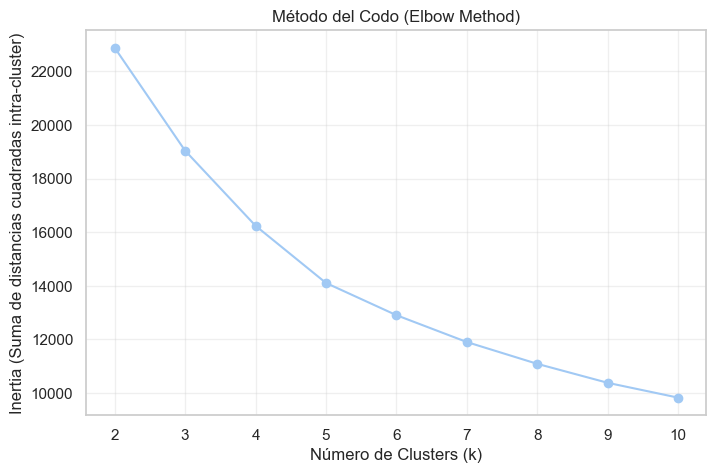

In [16]:
# =====================================================
# ⚙️ 3.1.1 Método del codo (Elbow Method)
# =====================================================

from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=100)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inertia (Suma de distancias cuadradas intra-cluster)")
plt.grid(True, alpha=0.3)
plt.show()


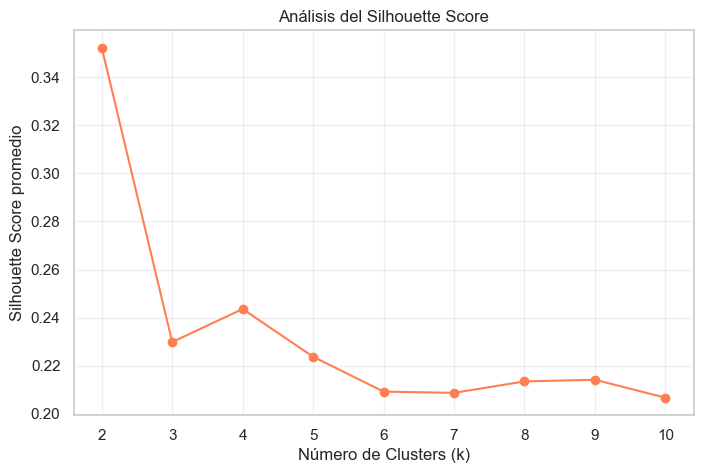

In [17]:
# =====================================================
# 💠 3.1.2 Análisis de Silhouette Score
# =====================================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=100)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# Gráfico de Silhouette
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='coral')
plt.title("Análisis del Silhouette Score")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score promedio")
plt.grid(True, alpha=0.3)
plt.show()


### 3.2 K-Means con K=4 y K=5

In [18]:
# =====================================================
# 🔹 3.2 Ejecución de K-Means con K=4 y K=5
# =====================================================

from sklearn.metrics import silhouette_score

resultados = {}

for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=100)
    labels = kmeans.fit_predict(df_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(df_scaled, labels)
    
    resultados[k] = {
        'inertia': inertia,
        'silhouette': silhouette,
        'centroids': pd.DataFrame(kmeans.cluster_centers_, columns=df_scaled.columns)
    }

    print(f"\nResultados para K={k}")
    print(f"Inertia: {inertia:.2f}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print("Centroides estandarizados:")
    display(resultados[k]['centroids'])



Resultados para K=4
Inertia: 16238.86
Silhouette Score: 0.2436
Centroides estandarizados:


,age,total_invested,risk_tolerance,months_active,app_sessions_month
0,0.407949,6.159145,0.114374,1.501453,0.996626
1,0.006215,-0.199748,0.759293,-0.386711,-0.321127
2,-0.056114,0.354720,0.108250,1.622537,1.433616
3,0.001351,-0.171798,-1.034576,-0.335420,-0.308878



Resultados para K=5
Inertia: 14104.13
Silhouette Score: 0.2237
Centroides estandarizados:


,age,total_invested,risk_tolerance,months_active,app_sessions_month
0,-0.604260,-0.207446,0.785031,-0.357313,-0.307676
1,0.407949,6.159145,0.114374,1.501453,0.996626
2,1.151596,-0.160881,0.291951,-0.355169,-0.290262
3,-0.065921,0.378066,0.101965,1.720356,1.514717
4,-0.326113,-0.168537,-1.100970,-0.309103,-0.281051


In [19]:
# =====================================================
# 🧭 3.2 Agregar etiquetas de cluster al dataset original
# =====================================================

# Usar K=4 como configuración base (recomendación del taller)
kmeans_4 = KMeans(n_clusters=4, random_state=42, init='k-means++', n_init=100)
df_limpio['cluster'] = kmeans_4.fit_predict(df_scaled)

# Ver distribución de usuarios por cluster
df_limpio['cluster'].value_counts().sort_index()


cluster
0      91
1    2769
2    1020
3    2149
Name: count, dtype: int64

### 3.3 Comparación y recomendación

In [20]:
# =====================================================
# 📊 3.3 Caracterización de los clusters (K=4)
# =====================================================

cluster_summary = df_limpio.groupby('cluster')[['age', 'total_invested', 'risk_tolerance', 
                                                'months_active', 'app_sessions_month']].mean().round(2)
cluster_summary


,age,total_invested,risk_tolerance,months_active,app_sessions_month
cluster,,,,,
0,34.76,6060886.23,2.75,19.67,24.92
1,31.69,184375.85,3.39,4.59,16.97
2,31.21,696782.36,2.74,20.64,27.56
3,31.65,210205.27,1.61,5.00,17.04


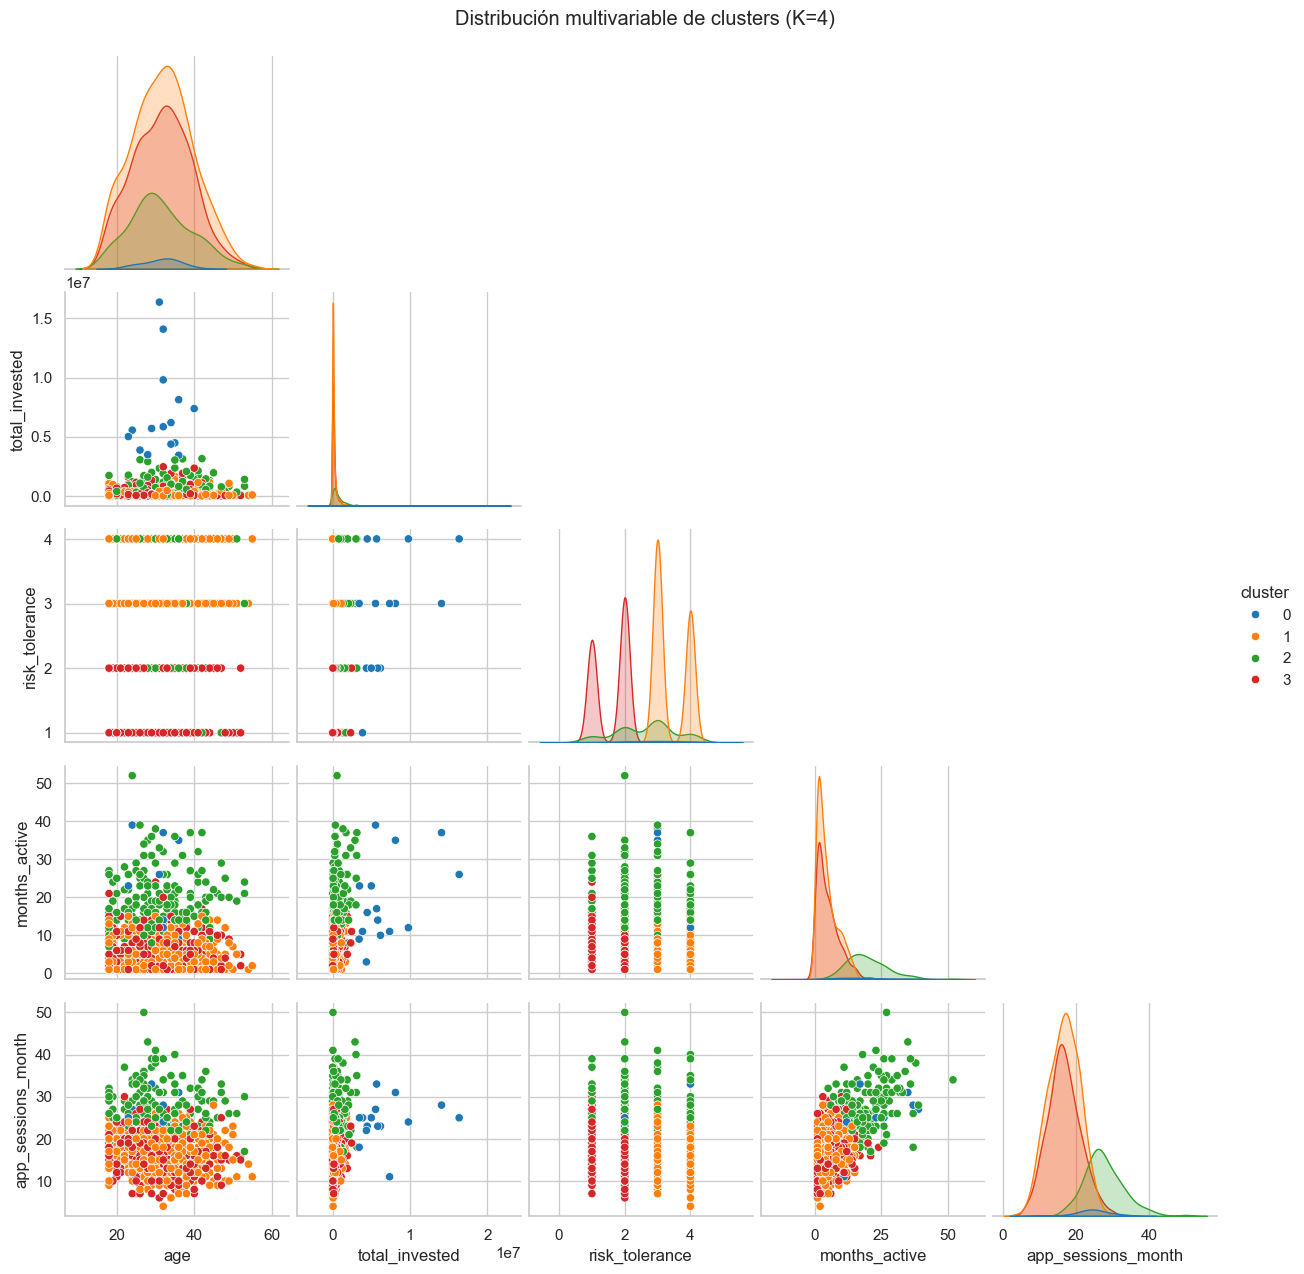

In [21]:
# =====================================================
# 🧩 Visualización comparativa de clusters (Pairplot)
# =====================================================

sns.pairplot(df_limpio.sample(1000), 
             vars=['age', 'total_invested', 'risk_tolerance', 'months_active', 'app_sessions_month'], 
             hue='cluster', palette='tab10', diag_kind='kde', corner=True)
plt.suptitle("Distribución multivariable de clusters (K=4)", y=1.02)
plt.show()


## 4️⃣ Análisis Estratégico
### 4.1 Segmento prioritario para Fintual Card

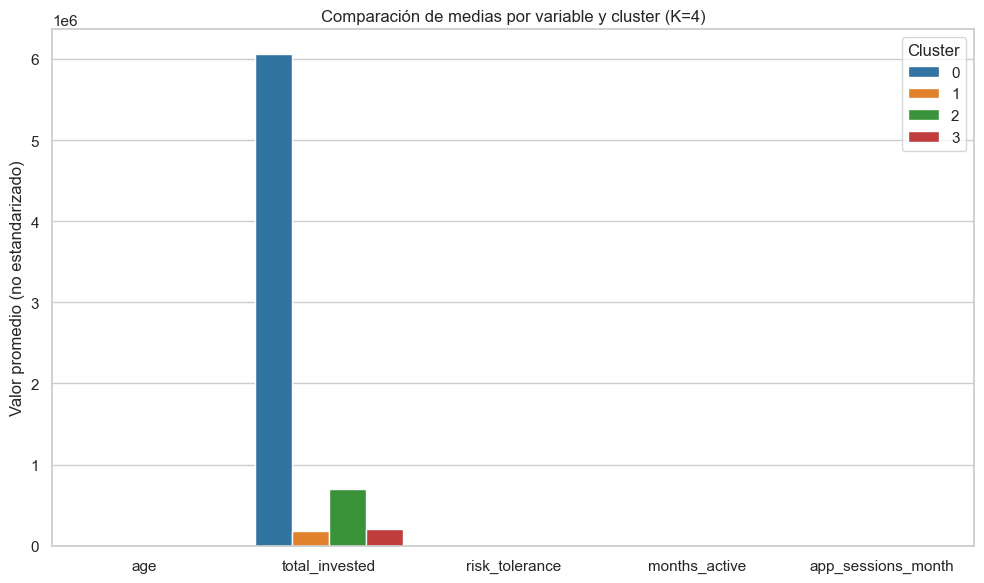

In [22]:
# =====================================================
# 📊 Promedios comparativos de los clusters (K=4)
# =====================================================

cluster_summary_plot = cluster_summary.reset_index().melt(id_vars='cluster', var_name='variable', value_name='valor')

plt.figure(figsize=(10,6))
sns.barplot(data=cluster_summary_plot, x='variable', y='valor', hue='cluster', palette='tab10')
plt.title("Comparación de medias por variable y cluster (K=4)")
plt.ylabel("Valor promedio (no estandarizado)")
plt.xlabel("")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [23]:
# =====================================================
# 📈 Identificación del segmento con mayor valor estratégico
# =====================================================

# Crear un índice de valor compuesto (ponderación simple o ajustable)
# Puedes ajustar los pesos según la prioridad estratégica de Fintual.
df_valor = cluster_summary.copy()
df_valor['engagement_index'] = df_valor['months_active'] * 0.5 + df_valor['app_sessions_month'] * 0.5
df_valor['financial_index'] = df_valor['total_invested'] * 0.7 + df_valor['risk_tolerance'] * 0.3

# Normalizar índices (opcional)
df_valor['valor_total'] = (df_valor['engagement_index'] + df_valor['financial_index']) / 2

# Ordenar por valor total
df_valor = df_valor.sort_values(by='valor_total', ascending=False)
display(df_valor)


,age,total_invested,risk_tolerance,months_active,app_sessions_month,engagement_index,financial_index,valor_total
cluster,,,,,,,,
0,34.76,6060886.23,2.75,19.67,24.92,22.295,4242621.186,2.121322e+06
2,31.21,696782.36,2.74,20.64,27.56,24.100,487748.474,2.438863e+05
3,31.65,210205.27,1.61,5.00,17.04,11.020,147144.172,7.357760e+04
1,31.69,184375.85,3.39,4.59,16.97,10.780,129064.112,6.453745e+04


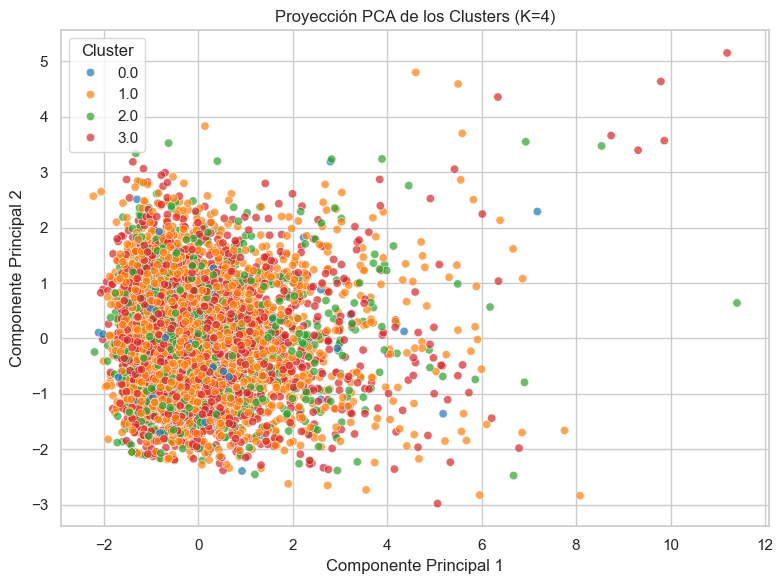

In [24]:
# =====================================================
# 📈 Visualización 2D de los clusters con PCA
# =====================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)
df_plot = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_plot['cluster'] = df_limpio['cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=0.7)
plt.title("Proyección PCA de los Clusters (K=4)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
